# Laboratorio 4 — Parte 2: Modelos con datos geoespaciales
**CC3084 Data Science · Universidad del Valle de Guatemala · Semestre II 2026**

Roberto Barreda (23354) · Javier España (23361) · Angel Esquit (23221)

---

## 1. Entorno de trabajo

In [1]:
%pip install -q pyproj

import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import seaborn as sns
from pyproj import Transformer
from scipy import ndimage

sns.set_theme(style="whitegrid")
np.seterr(divide="ignore", invalid="ignore")

DIR_DATOS = "../data"       # GeoTIFF crudos (Ejercicio 1-2 de la Parte I). Aun no existen.
DIR_SALIDA = "../outputs"   # huella + meta ya estan; el dataset de esta parte se guarda aqui tambien

print("rasterio", rasterio.__version__)
print("numpy   ", np.__version__)
print("pandas  ", pd.__version__)



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
rasterio 1.5.1
numpy    2.2.4
pandas   2.3.3


## 2. Configuración: fechas, bandas y umbrales

Mismas 11 fechas oficiales por lago y las mismas 9 bandas de la Parte I, para que Chl-a, NDCI,
NDVI, NDWI y FAI salgan calculados exactamente igual y sean comparables entre ambas entregas.

In [2]:
BANDAS = ["B02", "B03", "B04", "B05", "B07", "B08", "B8A", "B11", "B12"]
RESOLUCION_M = 20
EPS_REFLECTANCIA = 1e-4     # denominador minimo para que un cociente normalizado tenga sentido

UMBRAL_ALTO = 30.0          # mg Chla/m3 -- mismo corte que la Parte I; justificacion en el Ejercicio 2.2
UMBRAL_FAI = 0.08           # nata / vegetacion flotante (referencia, no se usa como predictor)

# Fecha -> (nubosidad %, satelite), igual que en el notebook de la Parte I
catalogo_atitlan = {
    "2025-01-18": (0.02, "Sentinel-2B"), "2025-04-13": (0.54, "Sentinel-2C"),
    "2025-05-13": (4.37, "Sentinel-2C"), "2025-07-17": (3.57, "Sentinel-2A"),
    "2025-11-21": (3.15, "Sentinel-2A"), "2025-12-29": (3.17, "Sentinel-2C"),
    "2026-02-12": (0.04, "Sentinel-2B"), "2026-03-24": (3.17, "Sentinel-2B"),
    "2026-04-13": (0.01, "Sentinel-2B"), "2026-04-28": (4.96, "Sentinel-2C"),
    "2026-07-22": (4.02, "Sentinel-2B"),
}
catalogo_amatitlan = {
    "2025-01-28": (0.06, "Sentinel-2B"), "2025-04-15": (0.09, "Sentinel-2A"),
    "2025-04-28": (1.03, "Sentinel-2B"), "2025-11-24": (0.50, "Sentinel-2B"),
    "2026-01-08": (0.77, "Sentinel-2C"), "2026-02-02": (0.39, "Sentinel-2B"),
    "2026-02-07": (0.02, "Sentinel-2C"), "2026-03-29": (0.01, "Sentinel-2C"),
    "2026-04-13": (0.09, "Sentinel-2B"), "2026-04-28": (4.96, "Sentinel-2C"),
    "2026-06-19": (13.00, "Sentinel-2A"),
}

LAGOS = {
    "atitlan": {"catalogo": catalogo_atitlan},
    "amatitlan": {"catalogo": catalogo_amatitlan},
}
for nombre, cfg in LAGOS.items():
    cfg["fechas"] = sorted(cfg["catalogo"])


def ruta_tif(lago, fecha):
    return os.path.join(DIR_DATOS, lago, f"{lago}_{fecha}.tif")


### Disponibilidad de datos ahora mismo

Esta celda funciona sin importar cuántas imágenes haya: solo reporta qué hay y qué falta.

In [3]:
filas = []
for lago, cfg in LAGOS.items():
    for fecha in cfg["fechas"]:
        filas.append({"lago": lago, "fecha": fecha, "disponible": os.path.exists(ruta_tif(lago, fecha))})
disponibilidad = pd.DataFrame(filas)

n_disp = disponibilidad["disponible"].sum()
print(f"{n_disp} de {len(disponibilidad)} imagenes disponibles en {DIR_DATOS}/")
if n_disp == 0:
    print("\nAun no hay imagenes descargadas. Corre primero la seccion "
          "'4. Descarga selectiva de bandas (Ejercicio 2)' del notebook de la Parte I "
          "(Lab4_Datos_Geoespaciales.ipynb) para generar data/<lago>/<lago>_<fecha>.tif")
elif n_disp < len(disponibilidad):
    print("\nHay imagenes parciales -- el resto de este notebook procesa solo las fechas disponibles.")

disponibilidad


22 de 22 imagenes disponibles en ../data/


,lago,fecha,disponible
0,atitlan,2025-01-18,True
1,atitlan,2025-04-13,True
2,atitlan,2025-05-13,True
3,atitlan,2025-07-17,True
4,atitlan,2025-11-21,True
5,atitlan,2025-12-29,True
6,atitlan,2026-02-12,True
7,atitlan,2026-03-24,True
8,atitlan,2026-04-13,True
9,atitlan,2026-04-28,True


## 3. Funciones del *Cyano Detection Script* (idénticas a la Parte I)

Se copian aquí (en vez de importarlas del otro notebook) para que este notebook sea autocontenido
y cualquiera del equipo pueda correrlo sin depender del kernel de la Parte I.

In [4]:
def leer_reflectancia(ruta):
    """Lee el GeoTIFF y devuelve bandas (reflectancia 0-1), el transform/CRS y la mascara sin_dato."""
    with rasterio.open(ruta) as src:
        datos = src.read().astype(np.float32)
        transform = src.transform
        crs = str(src.crs)
    if np.nanmax(datos) > 1.5:      # openEO entrega L2A como enteros escalados x10000
        datos = datos / 10000.0
    sin_dato = np.all(~np.isfinite(datos), axis=0) | np.all(datos == 0, axis=0)
    bandas = {nombre: datos[i] for i, nombre in enumerate(BANDAS)}
    return bandas, transform, crs, sin_dato


def indice_normalizado(a, b):
    """(a - b) / (a + b), devolviendo NaN donde el denominador se anula."""
    denominador = a + b
    with np.errstate(divide="ignore", invalid="ignore"):
        cociente = (a - b) / denominador
    return np.where(np.abs(denominador) < EPS_REFLECTANCIA, np.nan, cociente)


def indice_cianobacteria(b):
    """NDCI y su conversion a clorofila-a en mg/m3 (script de Sentinel Hub)."""
    evaluable = (b["B04"] > 0) & (b["B05"] > 0)
    ndci = np.where(evaluable, indice_normalizado(b["B05"], b["B04"]), np.nan)
    chla = 826.57 * ndci**3 - 176.43 * ndci**2 + 19 * ndci + 4.071
    return ndci, np.clip(chla, 0, 500.0)


def indice_algas_flotantes(b):
    """Floating Algae Index: FAI(B04, B07, B8A)."""
    return b["B07"] - b["B04"] - (b["B8A"] - b["B04"]) * (783 - 665) / (865 - 665)


## 4. Huella del lago, georreferencia y distancia a la orilla

`outputs/<lago>_huella.npz` y `outputs/<lago>_meta.json` ya están en el repo (los generó la
Parte I), así que no hace falta reprocesarlos. De la huella también derivamos una variable espacial
nueva: **distancia a la orilla**, útil como predictor (zonas costeras suelen concentrar más
nutrientes y floraciones que el centro del lago).

In [5]:
def cargar_huella(lago):
    with np.load(os.path.join(DIR_SALIDA, f"{lago}_huella.npz")) as datos:
        huella = datos["huella"]
    with open(os.path.join(DIR_SALIDA, f"{lago}_meta.json"), encoding="utf-8") as fh:
        meta = json.load(fh)
    distancia_orilla_m = ndimage.distance_transform_edt(huella) * RESOLUCION_M
    return huella, meta, distancia_orilla_m


_TRANSFORMERS = {}


def a_lonlat(x, y, crs):
    if crs not in _TRANSFORMERS:
        _TRANSFORMERS[crs] = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
    return _TRANSFORMERS[crs].transform(x, y)


# Sanity check: confirma que la huella y meta de ambos lagos si estan disponibles
for lago in LAGOS:
    huella, meta, _ = cargar_huella(lago)
    print(f"{lago:10s}: huella {huella.sum()} px validos, CRS {meta['crs']}, "
          f"{meta['ancho']}x{meta['alto']} px")


atitlan   : huella 301936 px validos, CRS EPSG:32615, 1380x876 px
amatitlan : huella 34436 px validos, CRS EPSG:32615, 681x459 px


## 5. Ejercicio 1 — Preparación de los datos para Machine Learning

### 1.1 – 1.2 Construcción del dataset por observación (píxel)

Cada fila = un píxel válido dentro de la huella del lago, en una fecha dada, con: coordenadas
(UTM y lon/lat), fecha, lago, las 9 bandas espectrales, NDVI, NDWI, NDCI, Chl-a, FAI y la distancia
a la orilla.

In [6]:
def construir_tabla_fecha(lago, fecha, huella, distancia_orilla_m):
    """Devuelve un DataFrame con un pixel valido por fila, o None si falta la imagen."""
    ruta = ruta_tif(lago, fecha)
    if not os.path.exists(ruta):
        return None

    bandas, transform, crs, sin_dato = leer_reflectancia(ruta)
    ndci, chla = indice_cianobacteria(bandas)
    fai = indice_algas_flotantes(bandas)
    ndvi = indice_normalizado(bandas["B08"], bandas["B04"])
    ndwi = indice_normalizado(bandas["B03"], bandas["B08"])

    # 1.3: solo pixeles dentro de la huella estable del lago, con dato y con Chl-a evaluable
    valido = huella & ~sin_dato & np.isfinite(chla)
    filas_px, cols_px = np.where(valido)
    if len(filas_px) == 0:
        return None

    xs, ys = rasterio.transform.xy(transform, filas_px, cols_px, offset="center")
    xs, ys = np.asarray(xs), np.asarray(ys)
    lons, lats = a_lonlat(xs, ys, crs)

    tabla = pd.DataFrame({
        "lago": lago,
        "fecha": pd.to_datetime(fecha),
        "fila_px": filas_px,
        "col_px": cols_px,
        "x_utm": xs,
        "y_utm": ys,
        "lon": lons,
        "lat": lats,
        "distancia_orilla_m": distancia_orilla_m[filas_px, cols_px],
    })
    for banda in BANDAS:
        tabla[banda] = bandas[banda][filas_px, cols_px]
    tabla["ndvi"] = ndvi[filas_px, cols_px]
    tabla["ndwi"] = ndwi[filas_px, cols_px]
    tabla["ndci"] = ndci[filas_px, cols_px]
    tabla["chla"] = chla[filas_px, cols_px]
    tabla["fai"] = fai[filas_px, cols_px]
    return tabla


In [7]:
tablas = []
for lago, cfg in LAGOS.items():
    huella, meta, distancia_orilla_m = cargar_huella(lago)
    for fecha in cfg["fechas"]:
        nubosidad, satelite = cfg["catalogo"][fecha]
        tabla = construir_tabla_fecha(lago, fecha, huella, distancia_orilla_m)
        if tabla is None:
            print(f"  {lago:10s} {fecha}: sin imagen (o sin pixeles validos), se omite por ahora")
            continue
        tabla["nubosidad_pct"] = nubosidad
        tabla["satelite"] = satelite
        tablas.append(tabla)

if tablas:
    df_pixeles = pd.concat(tablas, ignore_index=True)
    print(f"\n{len(df_pixeles)} observaciones (pixeles) construidas a partir de {len(tablas)} fecha(s)")
else:
    df_pixeles = pd.DataFrame()
    print("\nNo se construyo ninguna observacion todavia -- revisa que 'data/' tenga imagenes.")

df_pixeles.head()



3392024 observaciones (pixeles) construidas a partir de 22 fecha(s)


,lago,fecha,fila_px,col_px,x_utm,y_utm,lon,lat,distancia_orilla_m,B02,...,B8A,B11,B12,ndvi,ndwi,ndci,chla,fai,nubosidad_pct,satelite
0,atitlan,2025-01-18,22,847,697110.0,1631230.0,-91.168948,14.747765,20.0,0.01070,...,0.0026,0.0067,0.0061,0.482143,0.618391,0.283951,14.164664,0.000569,0.02,Sentinel-2B
1,atitlan,2025-01-18,22,848,697130.0,1631230.0,-91.168762,14.747764,20.0,0.01210,...,0.0024,0.0078,0.0069,-0.268817,0.843678,-0.145631,0.000000,-0.000421,0.02,Sentinel-2B
2,atitlan,2025-01-18,23,844,697050.0,1631210.0,-91.169507,14.747589,20.0,0.01065,...,0.0024,0.0064,0.0059,0.000000,0.895317,0.616162,142.154175,-0.000911,0.02,Sentinel-2B
3,atitlan,2025-01-18,23,852,697210.0,1631210.0,-91.168021,14.747577,20.0,0.01145,...,0.0026,0.0088,0.0070,0.528455,0.633528,0.600000,130.495346,0.003569,0.02,Sentinel-2B
4,atitlan,2025-01-18,24,853,697230.0,1631190.0,-91.167837,14.747395,20.0,0.01310,...,-0.0041,0.0055,0.0036,-0.425287,0.883178,-0.675676,0.000000,0.002484,0.02,Sentinel-2B


### 1.3 (continuación) — descartar fechas no confiables

`outputs/indices_<lago>.csv` (generado en la Parte I) ya marca con `Confiable = False` las fechas
cuya cobertura válida de la huella fue menor al 70% (ej. Amatitlán 2026-02-07). Reusamos ese
criterio en vez de reinventarlo, para ser consistentes con la Parte I.

In [8]:
if not df_pixeles.empty:
    confiabilidad = pd.concat([
        pd.read_csv(os.path.join(DIR_SALIDA, "indices_atitlan.csv"), parse_dates=["Fecha"]),
        pd.read_csv(os.path.join(DIR_SALIDA, "indices_amatitlan.csv"), parse_dates=["Fecha"]),
    ])[["Lago", "Fecha", "Confiable", "Nubosidad_pct"]]

    antes = len(df_pixeles)
    df_pixeles = df_pixeles.merge(
        confiabilidad, left_on=["lago", "fecha"], right_on=["Lago", "Fecha"], how="left"
    ).drop(columns=["Lago", "Fecha"])
    # Si una fecha nueva no aparece todavia en indices_<lago>.csv (porque ese csv no se ha
    # regenerado), no se descarta por defecto -- pero se marca para revisarla a mano.
    sin_info = df_pixeles["Confiable"].isna()
    if sin_info.any():
        print(f"Aviso: {sin_info.sum()} filas sin info de confiabilidad (fecha no esta en "
              f"indices_<lago>.csv todavia); no se descartan automaticamente, revisar a mano.")
    df_pixeles = df_pixeles[df_pixeles["Confiable"].fillna(True)]
    print(f"Se descartaron {antes - len(df_pixeles)} observaciones de fechas no confiables "
          f"(cobertura valida < 70% de la huella)")


Se descartaron 70697 observaciones de fechas no confiables (cobertura valida < 70% de la huella)


### 1.4 — Conteos, tipos de variable y datos faltantes

In [9]:
if not df_pixeles.empty:
    print(f"Observaciones totales: {len(df_pixeles)}")
    print("\nPor lago:")
    print(df_pixeles["lago"].value_counts())
    print("\nPor lago y fecha:")
    print(df_pixeles.groupby(["lago", "fecha"]).size())

    resumen_variables = pd.DataFrame({
        "tipo": df_pixeles.dtypes.astype(str),
        "pct_faltante": (df_pixeles.isna().mean() * 100).round(2),
    })
    resumen_variables


Observaciones totales: 3321327

Por lago:
lago
atitlan      2942535
amatitlan     378792
Name: count, dtype: int64

Por lago y fecha:
lago       fecha     
amatitlan  2025-01-28     34436
           2025-04-15     34436
           2025-04-28     34436
           2025-11-24     34436
           2026-01-08     34433
           2026-02-02     34436
           2026-02-07     34435
           2026-03-29     34436
           2026-04-13     34436
           2026-04-28     34436
           2026-06-19     34436
atitlan    2025-04-13    301936
           2025-05-13    301926
           2025-07-17    301841
           2025-11-21    287610
           2025-12-29    284979
           2026-02-12    256651
           2026-03-24    301935
           2026-04-13    301800
           2026-04-28    301936
           2026-07-22    301921
dtype: int64


### 1.5 — Análisis exploratorio de las variables

In [10]:
if not df_pixeles.empty:
    variables_eda = ["chla", "ndci", "ndvi", "ndwi", "fai", "distancia_orilla_m"] + BANDAS
    display(df_pixeles[variables_eda].describe().T.round(3))


,count,mean,std,min,25%,50%,75%,max
chla,3321327.0,5.194,10.470,0.000,2.884,4.020,4.579,500.000
ndci,3321327.0,0.002,0.148,-0.978,-0.042,-0.003,0.037,0.959
ndvi,3317523.0,-0.092,0.949,-72.000,-0.108,-0.042,0.003,84.500
ndwi,3321327.0,0.452,0.229,-54.400,0.300,0.428,0.562,32.800
fai,3321327.0,0.001,0.005,-0.054,-0.000,0.000,0.001,0.295
distancia_orilla_m,3321327.0,1196.907,959.823,20.000,353.836,963.328,1892.829,3667.424
B02,3321327.0,0.027,0.022,0.003,0.016,0.027,0.033,1.517
B03,3321327.0,0.024,0.023,0.003,0.014,0.020,0.026,1.382
B04,3321327.0,0.013,0.020,0.000,0.004,0.009,0.015,1.312
B05,3321327.0,0.015,0.025,0.000,0.004,0.009,0.017,1.418


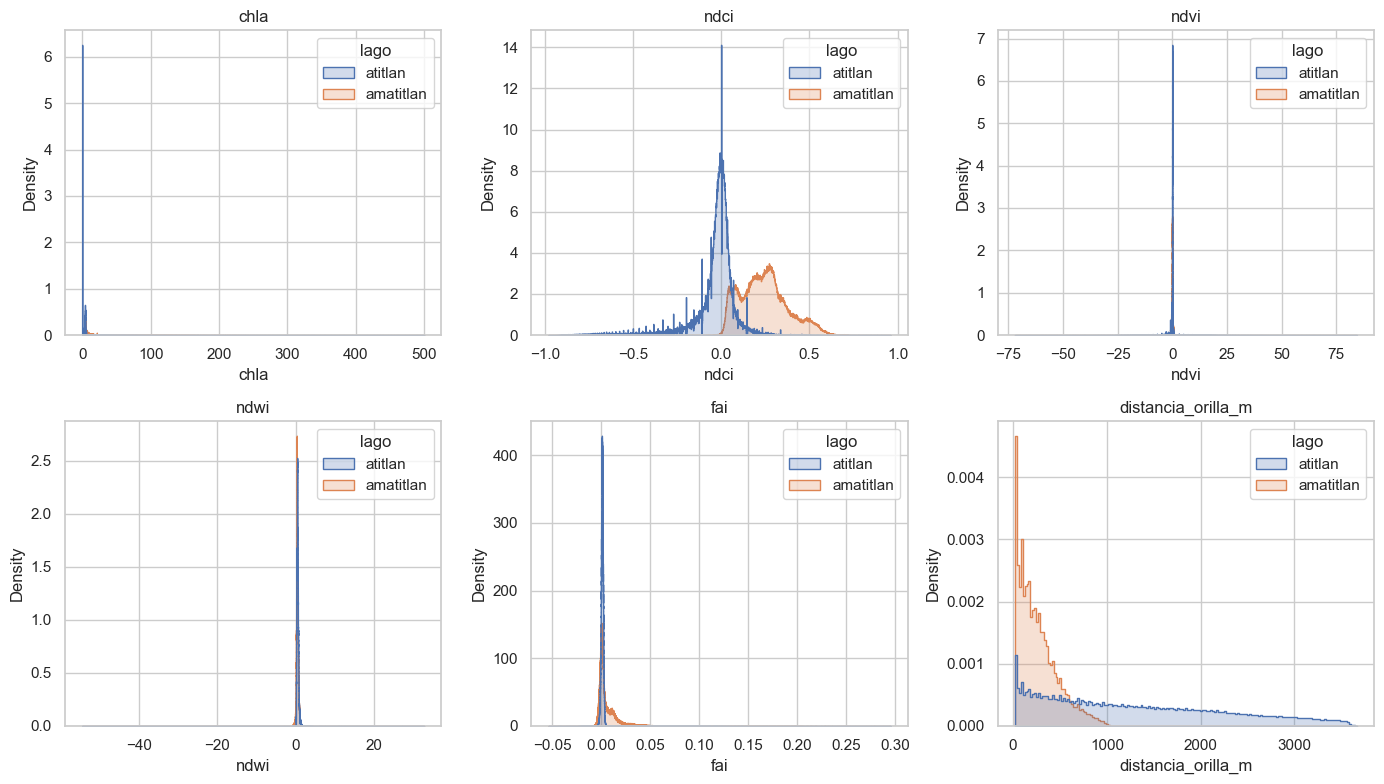

In [11]:
if not df_pixeles.empty:
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    for ax, col in zip(axes.flat, ["chla", "ndci", "ndvi", "ndwi", "fai", "distancia_orilla_m"]):
        sns.histplot(df_pixeles, x=col, hue="lago", element="step", stat="density",
                     common_norm=False, ax=ax)
        ax.set_title(col)
    plt.tight_layout()
    plt.show()


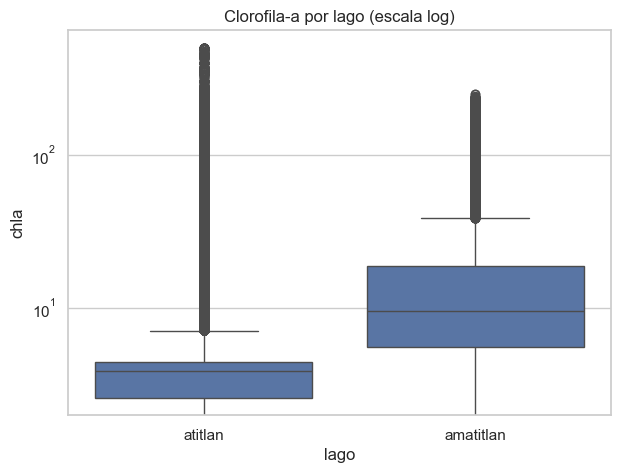

In [12]:
if not df_pixeles.empty:
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=df_pixeles, x="lago", y="chla")
    plt.yscale("log")
    plt.title("Clorofila-a por lago (escala log)")
    plt.show()


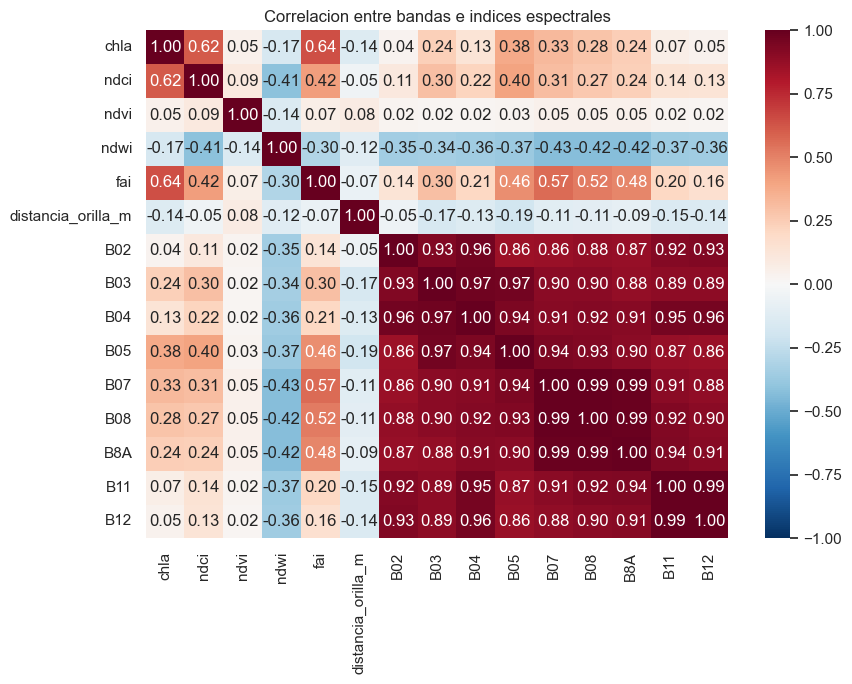

In [13]:
if not df_pixeles.empty:
    plt.figure(figsize=(9, 7))
    corr = df_pixeles[variables_eda].corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
    plt.title("Correlacion entre bandas e indices espectrales")
    plt.tight_layout()
    plt.show()


### 1.6 — Decisiones tomadas durante la preparación y limpieza (borrador)

*(completar/ajustar con los números reales una vez corrido con datos)*

- Se usó la **huella estable del lago** (`*_huella.npz`, Parte I) en vez del NDWI de cada fecha por
  separado, para que la superficie evaluada sea comparable entre fechas y no varíe con el nivel del
  agua o nubes puntuales.
- Se descartaron los píxeles marcados como `sin_dato` (reflectancia nula o no finita en alguna
  banda) y aquellos donde NDCI no es evaluable (reflectancia ≤ 0 en B04 o B05 — típico de sombras
  profundas en Atitlán, ver nota en la Parte I).
- Se descartaron completas las fechas con `Confiable = False` en `indices_<lago>.csv` (cobertura
  válida de la huella < 70%), en vez de intentar rescatar parcialmente esa fecha, para no mezclar
  observaciones de calidad muy distinta.
- Chl-a se dejó acotado a 0–500 mg/m³, el mismo tope de calibración declarado por los autores del
  script original — valores fuera de ese rango no son fiables físicamente.
